In [2]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

## Cinética Puntual a 1 Grupos de precursores

In [3]:
params = {'b': 765e-5, 'L': 1.76e-4, 'l': 0.0761}

def cp_updfn(t,x,u,params):
    n=x[0]
    c=x[1]
    
    r=u[0]
    # Extraer parámetros del diccionario params
    b = params.get('b', 765e-5)  # valor por defecto
    L = params.get('L', 1.76e-4)
    l = params.get('l', 0.0761)
    
    dn_dt=(r-b)/L*n+l*c
    dc_dt=b/L*n-l*c
    return ([dn_dt,dc_dt])

In [4]:
def cp_out(t,x,u,params):
    return(x[0],x[1])

In [5]:
cinetica=ctrl.nlsys(cp_updfn,cp_out,inputs=['rho'],outputs=['n','c'],states=['n', 'c'],name='cp')
print(cinetica)

<NonlinearIOSystem>: cp
Inputs (1): ['rho']
Outputs (2): ['n', 'c']
States (2): ['n', 'c']

Update: <function cp_updfn at 0x000001565E06E980>
Output: <function cp_out at 0x000001565E06EC00>


In [6]:
tiempo=np.linspace(0,2,1000)

r = 10e-5 #reactividad externa
rho= np.ones([len(tiempo),1])*r


n0=1 #flujo normalizado
c0=params.get('b')/params.get('L')*n0/params.get('l')

xeq=[n0,c0]

print(xeq)

[1, 571.1683191972286]


In [7]:
rta=ctrl.input_output_response(cinetica,
    tiempo,
    rho.T,
    xeq,
    solve_ivp_method='BDF',
    solve_ivp_kwargs={
        'rtol': 1e-8,    # tolerancia relativa
        'atol': 1e-10,   # tolerancia absoluta
        'max_step': 0.01 # paso máximo pequeño
    }
)

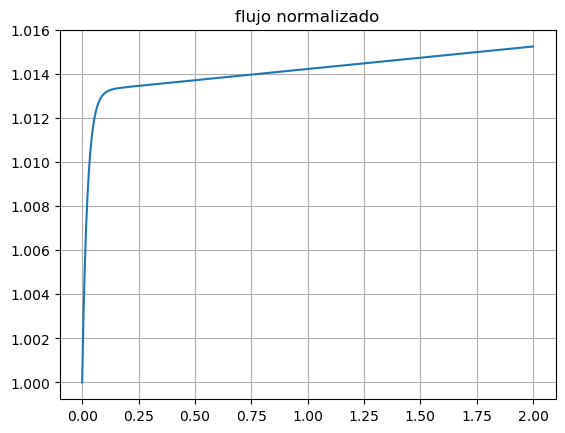

In [8]:
plt.plot(rta.time,rta.outputs[0])
plt.title('flujo normalizado')
plt.grid()

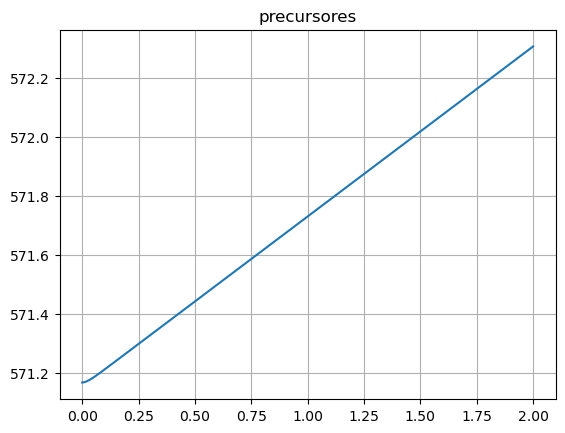

In [9]:
plt.plot(rta.time,rta.outputs[1])
plt.title('precursores')
plt.grid()

## Linealización con python-control

vemos como linealizar el sistema usando la biblioteca de control

**control.linearize(sys, xeq, ueq=None, t=0, params=None, \*\*kw)**

In [10]:

cp_lin=ctrl.linearize(cinetica, xeq, ueq=None, t=0, params=None)
cp_lin

StateSpace(
array([[-43.46590909,   0.0761    ],
       [ 43.46590909,  -0.0761    ]]),
array([[5681.81818182],
       [   0.        ]]),
array([[1., 0.],
       [0., 1.]]),
array([[0.],
       [0.]]),
states=2, outputs=2, inputs=1)

In [11]:
step_rta=ctrl.step_response(cp_lin*r,rta.time)

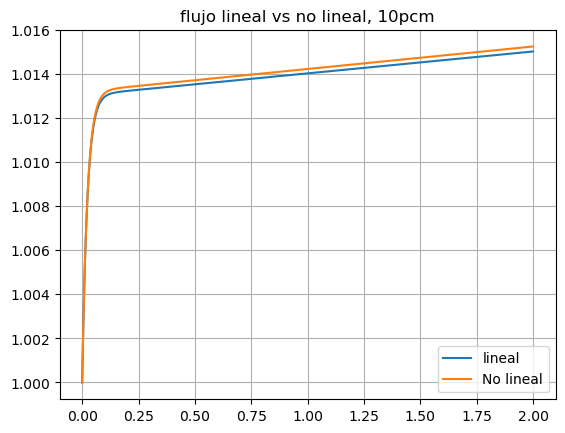

In [12]:
plt.plot(step_rta.time,step_rta.y[0,0]+n0,label={'lineal'})
plt.plot(rta.time,rta.outputs[0],label={'No lineal'})
plt.legend()
plt.title('flujo lineal vs no lineal, 10pcm')
plt.grid()

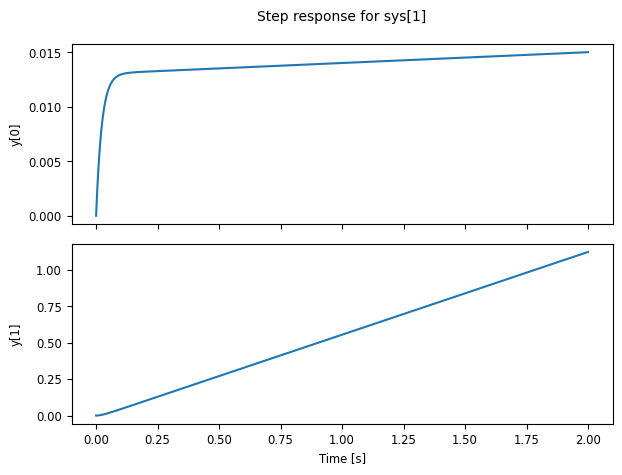

In [13]:
step_rta.plot()

In [14]:

#100pcm
rho_step=rho.T * 10
print('Escalón de reactividad [pcm]:', rho_step[(0,-1)]*1e5)

rta_100 = ctrl.input_output_response(
    cinetica,
    tiempo,
    rho_step,
    xeq,
    solve_ivp_method='BDF',
    solve_ivp_kwargs={
        'rtol': 1e-8,    # tolerancia relativa
        'atol': 1e-10,   # tolerancia absoluta
        'max_step': 0.01 # paso máximo pequeño
    }
)

Escalón de reactividad [pcm]: 100.0


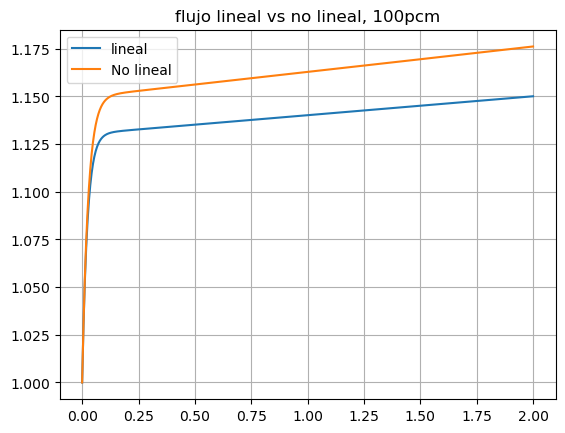

In [15]:
plt.plot(step_rta.time,step_rta.y[0,0]*10+n0,label={'lineal'})
plt.plot(rta_100.time,rta_100.outputs[0],label={'No lineal'})
plt.legend()
plt.title('flujo lineal vs no lineal, 100pcm')
plt.grid()

## Cinética Puntual a 6 Grupos de precursores

In [23]:
# parámetros de cinética puntual de 6 grupos de precursores
params = {
    'beta_i': np.array([0.000215,0.001424,0.001274,0.002568,0.000748,0.000273]),
    'Lambda': 1.76e-4,
    'lambda_i': np.array([1.24e-2,3.05e-2,0.111,0.301,1.14,3.01])
}

In [24]:
def cp6g_updfn(t,x,u,params):
    n=x[0]
    c=x[1:]

    rho=u[0]
    beta_i = params.get('beta_i', np.array([0.000215,0.001424,0.001274,0.002568,0.000748,0.000273]))
    beta  = np.sum(beta_i)
    Lambda = params.get('Lambda', 1.76e-4)
    lambda_i = params.get('lambda_i', np.array([1.24e-2,3.05e-2,0.111,0.301,1.14,3.01]))
    
    dn_dt = ((rho - beta) / Lambda) * n + np.sum(lambda_i * c)
    dc_dt = (beta_i / Lambda) * n - lambda_i * c

    dxdt = np.zeros(7)
    dxdt[0] = dn_dt
    dxdt[1:] = dc_dt
    
    return dxdt

In [25]:
def cp6g_out(t,x,u,params):
    return(x[0])

In [26]:
cp6g=ctrl.nlsys(cp6g_updfn,cp6g_out,inputs=['rho'],outputs=['n'],states=['n', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6'],name='cp6g')
print(cp6g)

<NonlinearIOSystem>: cp6g
Inputs (1): ['rho']
Outputs (1): ['n']
States (7): ['n', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6']

Update: <function cp6g_updfn at 0x000001566319A8E0>
Output: <function cp6g_out at 0x000001566319AC00>


In [29]:
# 6Grupos de precursores
N0=1#1e-8


Ci0=params.get('beta_i')/params.get('Lambda')/params.get('lambda_i')*N0
print("Ci0 = ", Ci0)

tiempo=np.linspace(0,2,1000)

r = 10e-5 #reactividad externa
rho= np.ones([len(tiempo),1])*r

xeq=[N0,Ci0]
print("xeq = ", xeq)

Ci0 =  [ 98.51539589 265.2757079   65.21294021  48.47478103   3.72807018
   0.5153277 ]
xeq =  [1, array([ 98.51539589, 265.2757079 ,  65.21294021,  48.47478103,
         3.72807018,   0.5153277 ])]


In [30]:

#10pcm
rho_step=rho.T
print('Escalón de reactividad [pcm]:', rho_step[(0,-1)]*1e5)

rta_cp6g_rho10 = ctrl.input_output_response(
    cp6g,
    tiempo,
    rho.T,
    xeq,
    solve_ivp_method='BDF',
    solve_ivp_kwargs={
        'rtol': 1e-8,    # tolerancia relativa
        'atol': 1e-10,   # tolerancia absoluta
        'max_step': 0.01 # paso máximo pequeño
    }
)

Escalón de reactividad [pcm]: 10.0


In [31]:
np.size(rta_cp6g_rho10.outputs)

1000

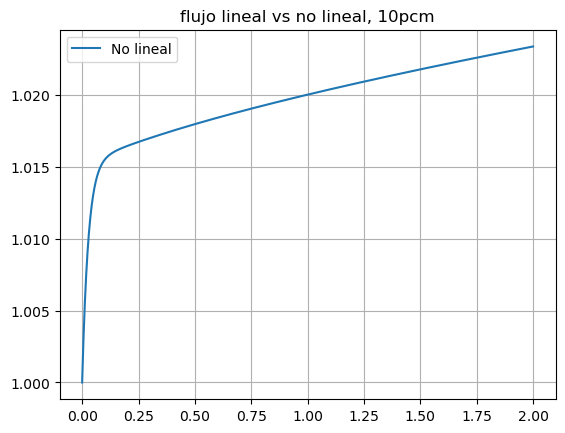

In [32]:
plt.plot(rta_cp6g_rho10.time,rta_cp6g_rho10.outputs,label={'No lineal'})
plt.legend()
plt.title('flujo lineal vs no lineal, 10pcm')
plt.grid()

## Linealización con python-control

vemos como linealizar el sistema usando la biblioteca de control

**control.linearize(sys, xeq, ueq=None, t=0, params=None, \*\*kw)**

In [33]:

cp6g_lin=ctrl.linearize(cp6g, xeq, ueq=None, t=0, params=None)
cp6g_lin

StateSpace(
array([[-3.69431818e+01,  1.24000010e-02,  3.05000043e-02,
         1.11000006e-01,  3.01000000e-01,  1.14000000e+00,
         3.01000000e+00],
       [ 1.22159091e+00, -1.23999999e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 8.09090909e+00,  0.00000000e+00, -3.05000007e-02,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 7.23863636e+00,  0.00000000e+00,  0.00000000e+00,
        -1.11000000e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.45909091e+01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -3.01000000e-01,  0.00000000e+00,
         0.00000000e+00],
       [ 4.25000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.14000000e+00,
         0.00000000e+00],
       [ 1.55113636e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -3.01000000e+00]]),
array([[5681.81818182],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ]]),
array([[1., 0., 0., 0., 0., 0., 0.]]),
array([[0.]]),
states=7, outputs=1, inputs=1)

In [34]:
step_rta=ctrl.step_response(cp6g_lin*r,rta_cp6g_rho10.time)

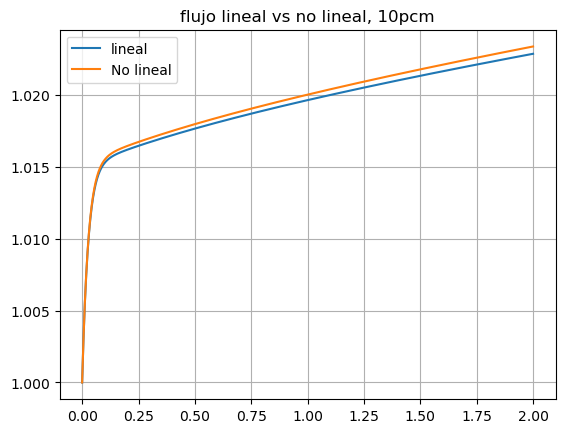

In [35]:
plt.plot(step_rta.time,step_rta.y[0,0]+n0,label={'lineal'})
plt.plot(rta_cp6g_rho10.time,rta_cp6g_rho10.outputs,label={'No lineal'})
plt.legend()
plt.title('flujo lineal vs no lineal, 10pcm')
plt.grid()

In [36]:
cp6g_lin.poles()

array([-3.73599671e+01+0.j, -2.88997292e+00+0.j, -1.02130276e+00+0.j,
       -1.94381418e-01+0.j, -6.81234075e-02+0.j,  2.90385931e-09+0.j,
       -1.43342100e-02+0.j])

In [37]:
cp6g_lin

StateSpace(
array([[-3.69431818e+01,  1.24000010e-02,  3.05000043e-02,
         1.11000006e-01,  3.01000000e-01,  1.14000000e+00,
         3.01000000e+00],
       [ 1.22159091e+00, -1.23999999e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 8.09090909e+00,  0.00000000e+00, -3.05000007e-02,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 7.23863636e+00,  0.00000000e+00,  0.00000000e+00,
        -1.11000000e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.45909091e+01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -3.01000000e-01,  0.00000000e+00,
         0.00000000e+00],
       [ 4.25000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.14000000e+00,
         0.00000000e+00],
       [ 1.55113636e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -3.01000000e+00]]),
array([[5681.81818182],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ],
       [   0.        ]]),
array([[1., 0., 0., 0., 0., 0., 0.]]),
array([[0.]]),
states=7, outputs=1, inputs=1)

<StateSpace sys[2]: ['u[0]'] -> ['y[0]']> $$ \left[\begin{array}{rllrllrllrllrllrllrll|rll} -36.&\hspace{-1em}9&\hspace{-1em}\phantom{\cdot}&0.&\hspace{-1em}0124&\hspace{-1em}\phantom{\cdot}&0.&\hspace{-1em}0305&\hspace{-1em}\phantom{\cdot}&0.&\hspace{-1em}111&\hspace{-1em}\phantom{\cdot}&0.&\hspace{-1em}301&\hspace{-1em}\phantom{\cdot}&1.&\hspace{-1em}14&\hspace{-1em}\phantom{\cdot}&3.&\hspace{-1em}01&\hspace{-1em}\phantom{\cdot}&5.&\hspace{-1em}68&\hspace{-1em}\cdot10^{3}\\ 1.&\hspace{-1em}22&\hspace{-1em}\phantom{\cdot}&-0.&\hspace{-1em}0124&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ 8.&\hspace{-1em}09&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&-0.&\hspace{-1em}0305&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ 7.&\hspace{-1em}24&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&-0.&\hspace{-1em}111&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ 14.&\hspace{-1em}6&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&-0.&\hspace{-1em}301&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ 4.&\hspace{-1em}25&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&-1.&\hspace{-1em}14&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ 1.&\hspace{-1em}55&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&-3.&\hspace{-1em}01&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ \hline 1\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}&0\phantom{.}&\hspace{-1em}&\hspace{-1em}\phantom{\cdot}\\ \end{array}\right] $$